LOGISTIC REGRESSION

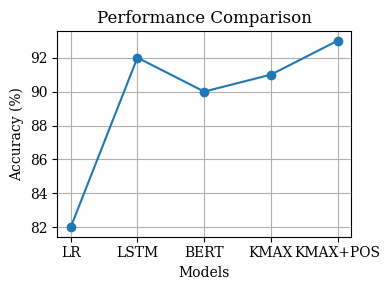

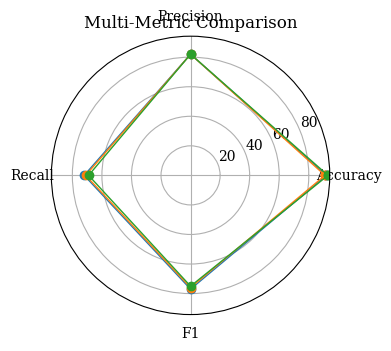

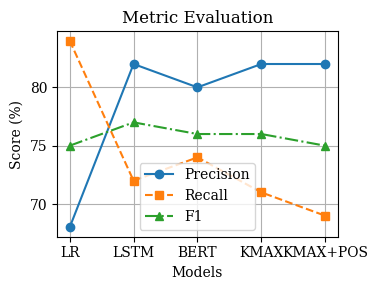

IEEE-style graphs generated.


In [ ]:
# IEEE-style plots: clean, minimal, publication-ready (matplotlib, no colors)

import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# DATA (from your results)
# -----------------------
models = ["LR", "LSTM", "BERT", "KMAX", "KMAX+POS"]
accuracy = [82, 92, 90, 91, 93]

precision = [0.68, 0.82, 0.80, 0.82, 0.82]
recall = [0.84, 0.72, 0.74, 0.71, 0.69]
f1 = [0.75, 0.77, 0.76, 0.76, 0.75]

# IEEE style settings
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10
})

# -----------------------
# 1. IEEE LINE GRAPH
# -----------------------
plt.figure(figsize=(4,3))
plt.plot(models, accuracy, marker='o')
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Performance Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


# -----------------------
# 2. IEEE RADAR (compact)
# -----------------------
labels = ["Accuracy", "Precision", "Recall", "F1"]
metrics = np.array([
    accuracy,
    np.array(precision)*100,
    np.array(recall)*100,
    np.array(f1)*100
])

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(4,4))

# plot only best 3 models (common in IEEE papers)
selected = [1, 3, 4]  # LSTM, KMAX, KMAX+POS

for i in selected:
    values = metrics[:, i]
    values = np.concatenate((values, [values[0]]))
    plt.polar(angles, values, marker='o', linewidth=1)

plt.xticks(angles[:-1], labels)
plt.title("Multi-Metric Comparison")
plt.tight_layout()
plt.show()


# -----------------------
# 3. IEEE METRIC CURVE
# (alternative to ROC when probs unavailable)
# -----------------------
plt.figure(figsize=(4,3))
x = np.arange(len(models))

plt.plot(x, np.array(precision)*100, marker='o', linestyle='-', label="Precision")
plt.plot(x, np.array(recall)*100, marker='s', linestyle='--', label="Recall")
plt.plot(x, np.array(f1)*100, marker='^', linestyle='-.', label="F1")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Score (%)")
plt.title("Metric Evaluation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("IEEE-style graphs generated.")


In [ ]:
!pip install -q scikit-learn pandas numpy datasets nltk


In [ ]:
import pandas as pd
import numpy as np

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, roc_auc_score

import nltk
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
jigsaw = pd.read_csv("train.csv", engine='python', on_bad_lines='skip')

TEXT_COL = "comment_text"
LABEL_COLS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

jigsaw[TEXT_COL] = jigsaw[TEXT_COL].fillna("")

In [ ]:
jigsaw["binary_toxic"] = (jigsaw[LABEL_COLS].sum(axis=1) > 0).astype(int)


In [ ]:
jigsaw.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,binary_toxic
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,0


In [ ]:
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    jigsaw[TEXT_COL],
    jigsaw["binary_toxic"],
    jigsaw[LABEL_COLS],
    test_size=0.2,
    random_state=42,
    stratify=jigsaw["binary_toxic"]
)


In [ ]:
tfidf = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [ ]:
lr_binary = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

lr_binary.fit(X_train_tfidf, y_train_bin)

y_pred_bin = lr_binary.predict(X_test_tfidf)
y_prob_bin = lr_binary.predict_proba(X_test_tfidf)[:, 1]

print("🔹 Binary Classification (Jigsaw)")
print(classification_report(y_test_bin, y_pred_bin))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_bin))


🔹 Binary Classification (Jigsaw)
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     28670
           1       0.68      0.84      0.75      3245

    accuracy                           0.94     31915
   macro avg       0.83      0.90      0.86     31915
weighted avg       0.95      0.94      0.95     31915

ROC-AUC: 0.9704961618932403


In [ ]:
lr_multi = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    )
)

lr_multi.fit(X_train_tfidf, y_train_multi)

y_pred_multi = lr_multi.predict(X_test_tfidf)
y_prob_multi = lr_multi.predict_proba(X_test_tfidf)


In [ ]:
print("🔹 Multi-Label Classification (Jigsaw)")
print(classification_report(
    y_test_multi,
    y_pred_multi,
    target_names=LABEL_COLS
))

macro_roc_auc = roc_auc_score(
    y_test_multi,
    y_prob_multi,
    average="macro"
)

print("Macro ROC-AUC:", macro_roc_auc)


🔹 Multi-Label Classification (Jigsaw)
               precision    recall  f1-score   support

        toxic       0.66      0.84      0.74      3046
 severe_toxic       0.26      0.83      0.40       305
      obscene       0.69      0.87      0.77      1662
       threat       0.24      0.66      0.36        98
       insult       0.57      0.86      0.69      1576
identity_hate       0.23      0.73      0.35       259

    micro avg       0.56      0.85      0.68      6946
    macro avg       0.44      0.80      0.55      6946
 weighted avg       0.61      0.85      0.70      6946
  samples avg       0.06      0.08      0.07      6946

Macro ROC-AUC: 0.9775579798339825


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
hate_ds = load_dataset("tdavidson/hate_speech_offensive", split="train")
hate_df = hate_ds.to_pandas()

hate_df["text"] = hate_df["tweet"].fillna("")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24783 [00:00<?, ? examples/s]

In [ ]:
hate_df["binary_toxic"] = hate_df["class"].apply(lambda x: 1 if x in [0,1] else 0)


In [ ]:
X_hate_tfidf = tfidf.transform(hate_df["text"])

y_hate_pred = lr_binary.predict(X_hate_tfidf)
y_hate_prob = lr_binary.predict_proba(X_hate_tfidf)[:,1]

print("🔹 Cross-Dataset Evaluation (Twitter Hate Speech)")
print(classification_report(hate_df["binary_toxic"], y_hate_pred))
print("ROC-AUC:", roc_auc_score(hate_df["binary_toxic"], y_hate_prob))


🔹 Cross-Dataset Evaluation (Twitter Hate Speech)
              precision    recall  f1-score   support

           0       0.52      0.71      0.60      4163
           1       0.94      0.87      0.90     20620

    accuracy                           0.84     24783
   macro avg       0.73      0.79      0.75     24783
weighted avg       0.87      0.84      0.85     24783

ROC-AUC: 0.8891269283021435


In [ ]:
import joblib

joblib.dump(lr_multi, "lr_multilabel_jigsaw.pkl")
joblib.dump(tfidf, "tfidf.pkl")


['tfidf.pkl']

BI-LSTM


In [ ]:
!pip install -q tensorflow keras scikit-learn pandas numpy


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dense, Dropout
)


In [ ]:
df = pd.read_csv("train.csv", engine='python', on_bad_lines='skip')

TEXT_COL = "comment_text"
LABEL_COLS = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df[TEXT_COL] = df[TEXT_COL].fillna("")

In [ ]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
df["binary_toxic"] = (df[LABEL_COLS].sum(axis=1) > 0).astype(int)


In [ ]:
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    df[TEXT_COL],
    df["binary_toxic"],
    df[LABEL_COLS],
    test_size=0.2,
    random_state=42,
    stratify=df["binary_toxic"]
)


In [ ]:
MAX_VOCAB = 50000
MAX_LEN = 150
EMB_DIM = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post")


In [ ]:
input_text = Input(shape=(MAX_LEN,))
embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(input_text)

x = Bidirectional(LSTM(64, return_sequences=False))(embedding)
x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid")(x)

bilstm_binary = Model(input_text, output)

bilstm_binary.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

bilstm_binary.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,084,609 (19.40 MB)

 Trainable params: 5,084,609 (19.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bilstm_binary.fit(
    X_train_pad,
    y_train_bin,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 636s 352ms/step - accuracy: 0.9343 - loss: 0.1940 - val_accuracy: 0.9622 - val_loss: 0.1068
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 618s 344ms/step - accuracy: 0.9698 - loss: 0.0855 - val_accuracy: 0.9598 - val_loss: 0.1167
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 606s 336ms/step - accuracy: 0.9781 - loss: 0.0608 - val_accuracy: 0.9602 - val_loss: 0.1194
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 625s 337ms/step - accuracy: 0.9851 - loss: 0.0432 - val_accuracy: 0.9568 - val_loss: 0.1392
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 617s 335ms/step - accuracy: 0.9887 - loss: 0.0309 - val_accuracy: 0.9558 - val_loss: 0.1774


In [ ]:
y_pred_bin = (bilstm_binary.predict(X_test_pad) > 0.5).astype(int)
y_prob_bin = bilstm_binary.predict(X_test_pad)

print("🔹 Binary Bi-LSTM (Jigsaw)")
print(classification_report(y_test_bin, y_pred_bin))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_bin))


998/998 ━━━━━━━━━━━━━━━━━━━━ 62s 59ms/step
998/998 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step
🔹 Binary Bi-LSTM (Jigsaw)
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     28670
           1       0.82      0.72      0.77      3245

    accuracy                           0.96     31915
   macro avg       0.90      0.85      0.87     31915
weighted avg       0.95      0.96      0.95     31915

ROC-AUC: 0.9576111890096272


In [ ]:
input_text = Input(shape=(MAX_LEN,))
embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(input_text)

x = Bidirectional(LSTM(64, return_sequences=False))(embedding)
x = Dropout(0.5)(x)

output = Dense(len(LABEL_COLS), activation="sigmoid")(x)

bilstm_multi = Model(input_text, output)

bilstm_multi.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

bilstm_multi.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 150, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,085,254 (19.40 MB)

 Trainable params: 5,085,254 (19.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
bilstm_multi.fit(
    X_train_pad,
    y_train_multi,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 671s 374ms/step - accuracy: 0.7861 - loss: 0.0274 - val_accuracy: 0.9866 - val_loss: 0.0627
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 673s 375ms/step - accuracy: 0.6372 - loss: 0.0235 - val_accuracy: 0.8877 - val_loss: 0.0647
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 795s 438ms/step - accuracy: 0.5390 - loss: 0.0206 - val_accuracy: 0.9123 - val_loss: 0.0703
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 793s 433ms/step - accuracy: 0.5236 - loss: 0.0179 - val_accuracy: 0.5808 - val_loss: 0.0789
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 701s 377ms/step - accuracy: 0.4084 - loss: 0.0148 - val_accuracy: 0.5845 - val_loss: 0.0855


In [ ]:
y_pred_multi = (bilstm_multi.predict(X_test_pad) > 0.5).astype(int)
y_prob_multi = bilstm_multi.predict(X_test_pad)

print("🔹 Multi-Label Bi-LSTM (Jigsaw)")
print(classification_report(
    y_test_multi,
    y_pred_multi,
    target_names=LABEL_COLS
))

print(
    "Macro ROC-AUC:",
    roc_auc_score(y_test_multi, y_prob_multi, average="macro")
)


998/998 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step
998/998 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step
🔹 Multi-Label Bi-LSTM (Jigsaw)
               precision    recall  f1-score   support

        toxic       0.76      0.73      0.74      3046
 severe_toxic       0.45      0.34      0.39       305
      obscene       0.81      0.77      0.79      1662
       threat       0.52      0.17      0.26        98
       insult       0.73      0.64      0.68      1576
identity_hate       0.47      0.30      0.37       259

    micro avg       0.74      0.68      0.71      6946
    macro avg       0.62      0.49      0.54      6946
 weighted avg       0.73      0.68      0.70      6946
  samples avg       0.06      0.06      0.06      6946

Macro ROC-AUC: 0.96719320873197


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout
)
from sklearn.metrics import classification_report, roc_auc_score


In [ ]:
MAX_VOCAB = 50000
MAX_LEN = 150
EMB_DIM = 100

input_text = Input(shape=(MAX_LEN,))
embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(input_text)

x = Conv1D(filters=128, kernel_size=5, activation="relu")(embedding)
x = GlobalMaxPooling1D()(x)
x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid")(x)

cnn_binary = Model(input_text, output)

cnn_binary.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

cnn_binary.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 150, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 146, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,064,257 (19.32 MB)

 Trainable params: 5,064,257 (19.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_binary.fit(
    X_train_pad,
    y_train_bin,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 233s 129ms/step - accuracy: 0.9337 - loss: 0.1935 - val_accuracy: 0.9593 - val_loss: 0.1152
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 260s 128ms/step - accuracy: 0.9677 - loss: 0.0893 - val_accuracy: 0.9583 - val_loss: 0.1200
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 273s 134ms/step - accuracy: 0.9797 - loss: 0.0570 - val_accuracy: 0.9556 - val_loss: 0.1409
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 229s 127ms/step - accuracy: 0.9869 - loss: 0.0366 - val_accuracy: 0.9564 - val_loss: 0.1629
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 230s 128ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9554 - val_loss: 0.1966


In [ ]:
y_pred_bin = (cnn_binary.predict(X_test_pad) > 0.5).astype(int)
y_prob_bin = cnn_binary.predict(X_test_pad)

print("🔹 Binary CNN")
print(classification_report(y_test_bin, y_pred_bin))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_bin))


998/998 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step
998/998 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step
🔹 Binary CNN
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     28670
           1       0.83      0.71      0.77      3245

    accuracy                           0.96     31915
   macro avg       0.90      0.85      0.87     31915
weighted avg       0.95      0.96      0.95     31915

ROC-AUC: 0.9516495233202001


In [ ]:
input_text = Input(shape=(MAX_LEN,))
embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(input_text)

x = Conv1D(filters=128, kernel_size=5, activation="relu")(embedding)
x = GlobalMaxPooling1D()(x)
x = Dropout(0.5)(x)

output = Dense(len(LABEL_COLS), activation="sigmoid")(x)

cnn_multi = Model(input_text, output)

cnn_multi.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [ ]:
cnn_multi.fit(
    X_train_pad,
    y_train_multi,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)

y_pred_multi = (cnn_multi.predict(X_test_pad) > 0.5).astype(int)
y_prob_multi = cnn_multi.predict(X_test_pad)

print("🔹 Multi-Label CNN")
print(classification_report(y_test_multi, y_pred_multi, target_names=LABEL_COLS))
print("Macro ROC-AUC:",
      roc_auc_score(y_test_multi, y_prob_multi, average="macro"))


Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 267s 149ms/step - accuracy: 0.7714 - loss: 0.0927 - val_accuracy: 0.9937 - val_loss: 0.0539
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 268s 149ms/step - accuracy: 0.9071 - loss: 0.0501 - val_accuracy: 0.9713 - val_loss: 0.0511
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 323s 150ms/step - accuracy: 0.8396 - loss: 0.0413 - val_accuracy: 0.6638 - val_loss: 0.0524
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 269s 150ms/step - accuracy: 0.7060 - loss: 0.0354 - val_accuracy: 0.6072 - val_loss: 0.0559
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 266s 148ms/step - accuracy: 0.6079 - loss: 0.0310 - val_accuracy: 0.6711 - val_loss: 0.0598
998/998 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step
998/998 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step
🔹 Multi-Label CNN
               precision    recall  f1-score   support

        toxic       0.78      0.75      0.76      3046
 severe_toxic       0.50      0.29      0.36       305
      obscene       0.82      0.76      0.79      1662
       thr

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
class KMaxPooling(tf.keras.layers.Layer):
    def __init__(self, k=3, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs):
        # inputs: (batch, time, channels)
        # Transpose to make 'time' dimension the last one for tf.nn.top_k
        transposed_inputs = tf.transpose(inputs, perm=[0, 2, 1])  # (batch, channels, time)
        # Apply top_k along the last dimension (time dimension)
        top_k_values, _ = tf.nn.top_k(transposed_inputs, k=self.k, sorted=True)
        # Reshape to (batch, k * channels)
        return tf.reshape(top_k_values, (tf.shape(inputs)[0], -1))

    def compute_output_shape(self, input_shape):
        # input_shape: (batch, time, channels)
        # After k-max pooling along time dimension and reshape, output is (batch, k * channels)
        return (input_shape[0], self.k * input_shape[-1])

In [ ]:
K = 3

input_text = Input(shape=(MAX_LEN,))
embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(input_text)

x = Conv1D(filters=128, kernel_size=5, activation="relu")(embedding)
x = KMaxPooling(k=K)(x)
x = Dropout(0.5)(x)

output = Dense(1, activation="sigmoid")(x)

kmax_binary = Model(input_text, output)

kmax_binary.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

kmax_binary.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 150, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 146, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ k_max_pooling (KMaxPooling)     │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,064,513 (19.32 MB)

 Trainable params: 5,064,513 (19.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
kmax_binary.fit(
    X_train_pad,
    y_train_bin,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)

y_pred_bin = (kmax_binary.predict(X_test_pad) > 0.5).astype(int)
y_prob_bin = kmax_binary.predict(X_test_pad)

print("🔹 Binary K-Max CNN")
print(classification_report(y_test_bin, y_pred_bin))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob_bin))

Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 303s 168ms/step - accuracy: 0.9357 - loss: 0.1970 - val_accuracy: 0.9597 - val_loss: 0.1124
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 320s 167ms/step - accuracy: 0.9686 - loss: 0.0855 - val_accuracy: 0.9602 - val_loss: 0.1158
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 323s 167ms/step - accuracy: 0.9805 - loss: 0.0546 - val_accuracy: 0.9584 - val_loss: 0.1449
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 299s 167ms/step - accuracy: 0.9882 - loss: 0.0337 - val_accuracy: 0.9557 - val_loss: 0.1715
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 301s 168ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9550 - val_loss: 0.2130
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step
🔹 Binary K-Max CNN
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     28670
           1       0.82      0.71      0.76      3245

    accuracy                           0.95     31915
   macro avg

In [ ]:
input_text = Input(shape=(MAX_LEN,))
embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(input_text)

x = Conv1D(filters=128, kernel_size=5, activation="relu")(embedding)
x = KMaxPooling(k=K)(x)
x = Dropout(0.5)(x)

output = Dense(len(LABEL_COLS), activation="sigmoid")(x)

kmax_multi = Model(input_text, output)

kmax_multi.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
kmax_multi.fit(
    X_train_pad,
    y_train_multi,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)

y_pred_multi = (kmax_multi.predict(X_test_pad) > 0.5).astype(int)
y_prob_multi = kmax_multi.predict(X_test_pad)

print("🔹 Multi-Label K-Max CNN")
print(classification_report(y_test_multi, y_pred_multi, target_names=LABEL_COLS))
print("Macro ROC-AUC:",
      roc_auc_score(y_test_multi, y_prob_multi, average="macro"))


Epoch 1/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 317s 175ms/step - accuracy: 0.7596 - loss: 0.1116 - val_accuracy: 0.9895 - val_loss: 0.0540
Epoch 2/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 299s 167ms/step - accuracy: 0.8278 - loss: 0.0485 - val_accuracy: 0.5732 - val_loss: 0.0522
Epoch 3/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 302s 168ms/step - accuracy: 0.7055 - loss: 0.0393 - val_accuracy: 0.5529 - val_loss: 0.0558
Epoch 4/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 302s 168ms/step - accuracy: 0.5760 - loss: 0.0312 - val_accuracy: 0.4658 - val_loss: 0.0605
Epoch 5/5
1796/1796 ━━━━━━━━━━━━━━━━━━━━ 300s 167ms/step - accuracy: 0.4600 - loss: 0.0268 - val_accuracy: 0.4128 - val_loss: 0.0743
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step
🔹 Multi-Label K-Max CNN
               precision    recall  f1-score   support

        toxic       0.87      0.65      0.74      3046
 severe_toxic       0.57      0.17      0.26       305
      obscene       0.87      0.67      0.76      1662
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
!pip install -q nltk


In [ ]:
import tensorflow as tf
import numpy as np
import nltk

from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, Dense, Dropout, Layer
)
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, roc_auc_score

nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
POS_WEIGHT = {
    "JJ": 1.5, "JJR": 1.5, "JJS": 1.5,   # adjectives
    "VB": 1.3, "VBD": 1.3, "VBG": 1.3,
    "VBN": 1.3, "VBP": 1.3, "VBZ": 1.3, # verbs
    "PRP": 1.2, "PRP$": 1.2,            # pronouns
}


In [ ]:
def pos_weight_sequence(text, max_len):
    tokens = nltk.word_tokenize(text.lower())
    tags = nltk.pos_tag(tokens)

    weights = [POS_WEIGHT.get(tag, 1.0) for _, tag in tags]
    weights = weights[:max_len]
    return weights + [1.0] * (max_len - len(weights))


In [ ]:
X_train_pos = np.array([
    pos_weight_sequence(t, MAX_LEN) for t in X_train
])

X_test_pos = np.array([
    pos_weight_sequence(t, MAX_LEN) for t in X_test
])


In [ ]:
class POSGuidedWeighting(Layer):
    def call(self, inputs):
        feature_maps, pos_weights = inputs
        pos_weights = tf.expand_dims(pos_weights, axis=-1)
        return feature_maps * pos_weights

In [ ]:
class AdaptiveKMaxPooling(Layer):
    def __init__(self, k_max=5, alpha=1.0, **kwargs):
        super().__init__(**kwargs)
        self.k_max = k_max
        self.alpha = alpha

    def call(self, inputs):
        # inputs: (batch, time, channels)
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        channels = tf.shape(inputs)[2]

        k = tf.minimum(
            self.k_max,
            tf.cast(tf.math.log(tf.cast(seq_len, tf.float32)) * self.alpha + 1, tf.int32)
        )

        # Transpose to make 'time' dimension the last one for tf.nn.top_k
        transposed_inputs = tf.transpose(inputs, perm=[0, 2, 1])  # (batch, channels, time)
        # Apply top_k along the last dimension (time dimension)
        top_k_values, _ = tf.nn.top_k(transposed_inputs, k=k, sorted=True)
        # Reshape to (batch, k * channels)
        return tf.reshape(top_k_values, (batch_size, -1))

    def compute_output_shape(self, input_shape):
        # input_shape: (batch, time, channels)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        channels = input_shape[2]

        if seq_len is None or channels is None:
            # If sequence length or channels are not statically known,
            # we cannot compute the exact output dimension
            return tf.TensorShape([batch_size, None])

        # Calculate k using static shapes for compute_output_shape
        k_val = min(self.k_max, int(tf.math.log(float(seq_len)) * self.alpha + 1))

        return tf.TensorShape([batch_size, k_val * channels])

In [ ]:
text_input = Input(shape=(MAX_LEN,))
pos_input = Input(shape=(MAX_LEN,))

embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(text_input)

conv = Conv1D(filters=128, kernel_size=5, activation="relu")(embedding)

pos_weighted = POSGuidedWeighting()([conv, pos_input])

adaptive_pool = AdaptiveKMaxPooling(k_max=5, alpha=1.2)(pos_weighted)

x = Dropout(0.5)(adaptive_pool)

output = Dense(len(LABEL_COLS), activation="sigmoid")(x)

model = Model(inputs=[text_input, pos_input], outputs=output)

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 150, 100)  │  5,000,000 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 146, 128)  │     64,128 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_guided_weighti… │ (None, 146, 128)  │          0 │ conv1d_5[0][0],   │
│ (POSGuidedWeightin… │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adaptive_k_max_poo… │ (None, 640)       │          0 │ pos_guided_weigh… │
│ (AdaptiveKMaxPooli… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 640)       │          0 │ adaptive_k_max_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 6)         │      3,846 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,067,974 (19.33 MB)

 Trainable params: 5,067,974 (19.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(
    [X_train_pad, X_train_pos],
    y_train_multi,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 206s 164ms/step - accuracy: 0.7795 - loss: 0.1247 - val_accuracy: 0.9543 - val_loss: 0.0528
Epoch 2/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 196s 160ms/step - accuracy: 0.7922 - loss: 0.0500 - val_accuracy: 0.6811 - val_loss: 0.0505
Epoch 3/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 212s 168ms/step - accuracy: 0.6976 - loss: 0.0392 - val_accuracy: 0.7603 - val_loss: 0.0547
Epoch 4/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 202s 165ms/step - accuracy: 0.5789 - loss: 0.0310 - val_accuracy: 0.6904 - val_loss: 0.0626
Epoch 5/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 196s 159ms/step - accuracy: 0.4764 - loss: 0.0248 - val_accuracy: 0.4289 - val_loss: 0.0690


In [ ]:
y_pred = (model.predict([X_test_pad, X_test_pos]) > 0.5).astype(int)
y_prob = model.predict([X_test_pad, X_test_pos])

print("🔹 POS-Guided Adaptive K-Max CNN")
print(classification_report(y_test_multi, y_pred, target_names=LABEL_COLS))

print(
    "Macro ROC-AUC:",
    roc_auc_score(y_test_multi, y_prob, average="macro")
)


682/682 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step
682/682 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step
🔹 POS-Guided Adaptive K-Max CNN
               precision    recall  f1-score   support

        toxic       0.80      0.70      0.75      2095
 severe_toxic       0.40      0.34      0.37       195
      obscene       0.87      0.66      0.75      1178
       threat       0.48      0.21      0.29        62
       insult       0.76      0.60      0.67      1091
identity_hate       0.49      0.26      0.34       204

    micro avg       0.78      0.63      0.70      4825
    macro avg       0.63      0.46      0.53      4825
 weighted avg       0.78      0.63      0.69      4825
  samples avg       0.06      0.06      0.06      4825

Macro ROC-AUC: 0.9517815602652467


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from datasets import load_dataset

hate_ds = load_dataset("tdavidson/hate_speech_offensive", split="train")
hate_df = hate_ds.to_pandas()

hate_df["text"] = hate_df["tweet"].fillna("")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.63M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24783 [00:00<?, ? examples/s]

In [ ]:
hate_df["binary_toxic"] = hate_df["class"].apply(
    lambda x: 1 if x in [0, 1] else 0
)


In [ ]:
X_hate_seq = tokenizer.texts_to_sequences(hate_df["text"])
X_hate_pad = pad_sequences(
    X_hate_seq,
    maxlen=MAX_LEN,
    padding="post"
)


In [ ]:
X_hate_pos = np.array([
    pos_weight_sequence(t, MAX_LEN)
    for t in hate_df["text"]
])


In [ ]:
text_input = Input(shape=(MAX_LEN,))
pos_input = Input(shape=(MAX_LEN,))

embedding = Embedding(MAX_VOCAB, EMB_DIM, input_length=MAX_LEN)(text_input)

conv = Conv1D(filters=128, kernel_size=5, activation="relu")(embedding)

pos_weighted = POSGuidedWeighting()([conv, pos_input])

adaptive_pool = AdaptiveKMaxPooling(k_max=5, alpha=1.2)(pos_weighted)

x = Dropout(0.5)(adaptive_pool)

binary_output = Dense(1, activation="sigmoid")(x)

binary_model = Model(
    inputs=[text_input, pos_input],
    outputs=binary_output
)

binary_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Transfer shared weights
for layer_bin, layer_multi in zip(binary_model.layers, model.layers):
    if layer_bin.name == layer_multi.name:
        layer_bin.set_weights(layer_multi.get_weights())


In [ ]:
y_hate_prob = binary_model.predict([X_hate_pad, X_hate_pos])
y_hate_pred = (y_hate_prob > 0.5).astype(int)


775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("🔹 Cross-Dataset Generalization (POS-Adaptive K-Max CNN)")
print(classification_report(
    hate_df["binary_toxic"],
    y_hate_pred
))

print(
    "ROC-AUC:",
    roc_auc_score(hate_df["binary_toxic"], y_hate_prob)
)


🔹 Cross-Dataset Generalization (POS-Adaptive K-Max CNN)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4163
           1       0.83      1.00      0.91     20620

    accuracy                           0.83     24783
   macro avg       0.42      0.50      0.45     24783
weighted avg       0.69      0.83      0.76     24783

ROC-AUC: 0.4502716182675284


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
class POSGuidedWeighting(tf.keras.layers.Layer):
    def call(self, inputs):
        feature_maps, pos_weights = inputs
        # Get the sequence length from the feature maps after convolution
        seq_len_after_conv = tf.shape(feature_maps)[1]
        # Slice pos_weights to match this length
        pos_weights_sliced = pos_weights[:, :seq_len_after_conv]
        pos_weights_expanded = tf.expand_dims(pos_weights_sliced, axis=-1)
        return feature_maps * pos_weights_expanded

In [ ]:
class AdaptiveKMaxPooling(tf.keras.layers.Layer):
    def __init__(self, k_max=5, alpha=1.2, **kwargs):
        super().__init__(**kwargs)
        self.k_max = k_max
        self.alpha = alpha

    def call(self, inputs):
        # inputs: (batch, time, channels)
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        channels = tf.shape(inputs)[2]

        k = tf.minimum(
            self.k_max,
            tf.cast(tf.math.log(tf.cast(seq_len, tf.float32)) * self.alpha + 1, tf.int32)
        )

        # Transpose to make 'time' dimension the last one for tf.nn.top_k
        transposed_inputs = tf.transpose(inputs, perm=[0, 2, 1])  # (batch, channels, time)
        # Apply top_k along the last dimension (time dimension)
        top_k_values, _ = tf.nn.top_k(transposed_inputs, k=k, sorted=True)
        # Reshape to (batch, k * channels)
        return tf.reshape(top_k_values, (batch_size, -1))

    def compute_output_shape(self, input_shape):
        # input_shape: (batch, time, channels)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        channels = input_shape[2]

        if seq_len is None or channels is None:
            # If sequence length or channels are not statically known,
            # we cannot compute the exact output dimension
            return tf.TensorShape([batch_size, None])

        # Calculate k using static shapes for compute_output_shape
        k_val = min(self.k_max, int(tf.math.log(float(seq_len)) * self.alpha + 1))

        return tf.TensorShape([batch_size, k_val * channels])

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Conv1D, Dense, Dropout
from tensorflow.keras.models import Model

text_input = Input(shape=(MAX_LEN,))
pos_input = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=MAX_VOCAB,
    output_dim=EMB_DIM,
    input_length=MAX_LEN
)(text_input)

conv = Conv1D(
    filters=128,
    kernel_size=5,
    activation="relu"
)(embedding)

pos_weighted = POSGuidedWeighting()([conv, pos_input])

adaptive_pool = AdaptiveKMaxPooling(k_max=5, alpha=1.2)(pos_weighted)

x = Dropout(0.5)(adaptive_pool)

output = Dense(1, activation="sigmoid")(x)

binary_pos_adaptive_kmax = Model(
    inputs=[text_input, pos_input],
    outputs=output
)

binary_pos_adaptive_kmax.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

binary_pos_adaptive_kmax.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 150, 100)  │  5,000,000 │ input_layer_20[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 146, 128)  │     64,128 │ embedding_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_21      │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_guided_weighti… │ (None, 146, 128)  │          0 │ conv1d_10[0][0],  │
│ (POSGuidedWeightin… │                   │            │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adaptive_k_max_poo… │ (None, 640)       │          0 │ pos_guided_weigh… │
│ (AdaptiveKMaxPooli… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 640)       │          0 │ adaptive_k_max_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        641 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,064,769 (19.32 MB)

 Trainable params: 5,064,769 (19.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
binary_pos_adaptive_kmax.fit(
    [X_train_pad, X_train_pos],
    y_train_bin,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 212s 171ms/step - accuracy: 0.9269 - loss: 0.2192 - val_accuracy: 0.9623 - val_loss: 0.1059
Epoch 2/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 251s 162ms/step - accuracy: 0.9699 - loss: 0.0823 - val_accuracy: 0.9615 - val_loss: 0.1156
Epoch 3/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 196s 159ms/step - accuracy: 0.9816 - loss: 0.0506 - val_accuracy: 0.9578 - val_loss: 0.1349
Epoch 4/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 202s 159ms/step - accuracy: 0.9907 - loss: 0.0274 - val_accuracy: 0.9531 - val_loss: 0.1689
Epoch 5/5
1227/1227 ━━━━━━━━━━━━━━━━━━━━ 200s 163ms/step - accuracy: 0.9946 - loss: 0.0174 - val_accuracy: 0.9540 - val_loss: 0.2173


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = (binary_pos_adaptive_kmax.predict([X_test_pad, X_test_pos]) > 0.5).astype(int)
y_prob = binary_pos_adaptive_kmax.predict([X_test_pad, X_test_pos])

print("🔹 Binary POS-Adaptive K-Max CNN (Jigsaw)")
print(classification_report(y_test_bin, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_bin, y_prob))


682/682 ━━━━━━━━━━━━━━━━━━━━ 47s 69ms/step
682/682 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step
🔹 Binary POS-Adaptive K-Max CNN (Jigsaw)
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     19590
           1       0.82      0.69      0.75      2223

    accuracy                           0.95     21813
   macro avg       0.89      0.84      0.86     21813
weighted avg       0.95      0.95      0.95     21813

ROC-AUC: 0.9451657540075369


In [ ]:
# Tokenize Twitter text using SAME tokenizer
twitter_seq = tokenizer.texts_to_sequences(hate_df["text"])
twitter_pad = pad_sequences(twitter_seq, maxlen=MAX_LEN, padding="post")

twitter_pos = np.array([
    pos_weight_sequence(t, MAX_LEN) for t in hate_df["text"]
])

y_twitter_pred = (binary_pos_adaptive_kmax.predict(
    [twitter_pad, twitter_pos]) > 0.5).astype(int)

y_twitter_prob = binary_pos_adaptive_kmax.predict(
    [twitter_pad, twitter_pos])

print("🔹 Cross-Dataset (Twitter → Binary)")
print(classification_report(hate_df["binary_toxic"], y_twitter_pred))
print("ROC-AUC:", roc_auc_score(hate_df["binary_toxic"], y_twitter_prob))


775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step
775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step
🔹 Cross-Dataset (Twitter → Binary)
              precision    recall  f1-score   support

           0       0.44      0.83      0.58      4163
           1       0.96      0.79      0.87     20620

    accuracy                           0.80     24783
   macro avg       0.70      0.81      0.72     24783
weighted avg       0.87      0.80      0.82     24783

ROC-AUC: 0.8880713844866315
